In [1]:
import pandas as pd
import numpy as np
from rdkit.Chem import rdMolDescriptors, Descriptors
from rdkit import Chem

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import QuantileTransformer

In [2]:
df = pd.read_csv('test_feats.csv')
df.isnull().values.any()

False

In [3]:
df

,node,SMR_VSA1,NumRotatableBonds,Chi4v,PEOE_VSA14,VSA_EState3,NumHAcceptors,BCUT2D_MRLOW,PEOE_VSA6,Chi3n,...,VSA_EState7,AvgIpc,EState_VSA4,FractionCSP3,VSA_EState8,Chi1v,FpDensityMorgan1,qed,NumHeteroatoms,Ipc
0,F,9.901065,3,0.955337,5.969305,8.518312,2,-0.137996,30.331835,1.615638,...,0.385093,2.057052,5.563451,0.222222,0.000000,3.722225,1.416667,0.690463,3,526.605419
1,F,9.901065,3,0.955337,5.969305,8.518312,2,-0.137996,30.331835,1.615638,...,0.385093,2.057052,5.563451,0.222222,0.000000,3.722225,1.416667,0.690463,3,526.605419
2,P,9.901065,1,0.895327,5.969305,11.207222,2,-0.138517,0.000000,1.358409,...,1.784028,2.115968,19.386400,0.800000,0.858102,2.766883,1.750000,0.498209,3,93.102593
3,I,9.901065,3,0.497328,5.969305,8.358519,2,-0.139247,20.268296,1.542155,...,0.812963,1.843450,6.420822,0.833333,3.756204,3.075778,1.777778,0.583947,3,75.581432
4,V,9.901065,2,0.285154,5.969305,8.227407,2,-0.139040,13.847474,1.003387,...,0.000000,1.640336,0.000000,0.800000,3.553148,2.537773,1.625000,0.536977,3,39.368066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,D,19.802129,3,0.275438,11.938611,16.031991,3,-0.144488,0.000000,0.711731,...,-0.532407,1.634374,0.000000,0.500000,0.000000,2.239272,1.444444,0.452021,5,60.471844
1957,A,9.901065,1,0.000000,5.969305,7.865741,2,-0.137563,0.000000,0.389528,...,0.000000,1.360964,0.000000,0.666667,1.418981,1.627090,2.000000,0.451352,3,13.609640
1958,A,9.901065,1,0.000000,5.969305,7.865741,2,-0.137563,0.000000,0.389528,...,0.000000,1.360964,0.000000,0.666667,1.418981,1.627090,2.000000,0.451352,3,13.609640
1959,C,9.901065,2,0.234278,5.969305,8.008102,3,-0.137419,0.000000,0.513894,...,0.000000,1.645711,0.000000,0.666667,0.000000,2.406671,2.000000,0.424382,4,27.977093


In [4]:
nodes = df['node']
numeric_columns = df.drop(columns=['node'])

# Initialize the QuantileTransformer
quantile_transformer = QuantileTransformer(output_distribution='normal', n_quantiles=len(df))

# Fit and transform the numeric columns
normalized_data = quantile_transformer.fit_transform(numeric_columns)

# Create a new DataFrame with the normalized data
normalized_df = pd.DataFrame(normalized_data, columns=numeric_columns.columns)

# Add the 'node' column back to the DataFrame
normalized_df['node'] = nodes.values

# Reorder columns to have 'node' as the first column if needed
normalized_df = normalized_df[['node'] + numeric_columns.columns.tolist()]

In [5]:
normalized_df_unique = normalized_df.drop_duplicates('node', keep='first')
node_dict = normalized_df_unique.set_index('node').apply(lambda row: row.tolist(), axis=1).to_dict()

In [7]:
node_dict

{'F': [-0.23818876080686271,
  0.29117384194347307,
  1.4323600124349838,
  -0.052458621329943174,
  0.6317488216832727,
  -5.199337582605575,
  0.4403358524111358,
  5.19933758270342,
  1.4323600124349838,
  -0.553981017814928,
  -5.199337582605575,
  -5.199337582605575,
  5.19933758270342,
  -5.199337582605575,
  0.04861704033946377,
  -5.199337582605575,
  1.1640894710216174,
  0.22242944531127798,
  -5.199337582605575,
  1.3051648079050855,
  0.25532850217371655,
  1.6041841409640576,
  0.35927716512989555,
  -5.199337582605575,
  -5.199337582605575,
  0.015986830666930078,
  1.1974724770061187,
  1.180616509622805,
  1.8158866922529886,
  -0.4808652878682261,
  -0.9081944228127321,
  -5.199337582605575,
  0.3125904471701344,
  -0.20607196958332727,
  -5.199337582605575,
  -0.20541884508847177,
  1.4199843237682623,
  1.4323600124349838,
  1.421738975971941,
  -0.4945492018791881,
  -0.2533471031357997,
  5.19933758270342,
  0.5251343538696833,
  -1.284464172168705,
  1.43236001243

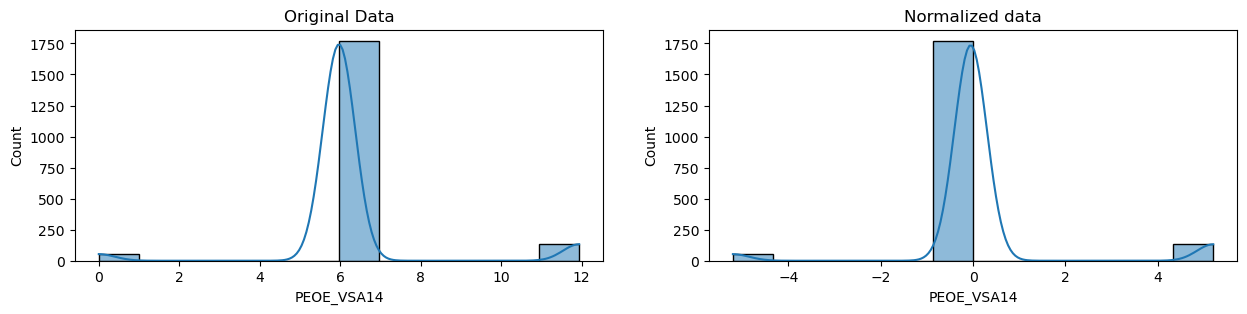

In [6]:
col = 'PEOE_VSA14'

fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(df[col], ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_df[col], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Assuming df is your original DataFrame and normalized_df is the DataFrame with normalized data
numeric_columns = df.drop(columns=['node']).columns

# Create a PdfPages object to save multiple plots in one PDF
with PdfPages('all_plots.pdf') as pdf:
    for col in numeric_columns:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        
        # Plot the original data
        sns.histplot(df[col], ax=ax[0], kde=True, legend=False)
        ax[0].set_title(f"Original Data: {col}")
        
        # Plot the normalized data
        sns.histplot(normalized_df[col], ax=ax[1], kde=True, legend=False)
        ax[1].set_title(f"Normalized Data: {col}")
        
        # Save the current figure to the PDF
        pdf.savefig(fig)
        
        # Close the current figure
        plt.close(fig)